# Coldwell Complex ca. 1107 Ma paleomagnetic pole

## Geologic setting

The Coldwell Complex is a large (>350 km²) multiphase alkaline intrusive complex
on the north shore of Lake Superior near Marathon, Ontario — the largest alkaline
complex in North America. It is a subcircular composite intrusion approximately
25 km in diameter that intrudes Archean supracrustal and granitoid rocks of the
Superior Province, and it was emplaced during magmatism of the Midcontinent Rift.
Following Lewchuk and Symons (1990), Kulakov, Smirnov and Diehl (2014) group the
complex into three intrusive centers: **Center A** (the eastern gabbro and
ferroaugite syenite; reversed polarity), **Center B** (the western gabbro and
syenite; normal polarity), and **Center C** (the central biotite gabbro,
nepheline syenite, and syenite of the Geordie Lakes area; reversed polarity), cut
by minor diabase dikes.

## Geochronology

Heaman and Machado (1992) dated several centers by U-Pb (zircon/baddeleyite). The
**reversed-polarity** eastern gabbro (Center A) gives the most precise dates,
**1108 ± 1 Ma** and 1107 +5/−1 Ma, and the central nepheline syenite (Center C,
also reversed) gives a comparable 1109 +8/−4 Ma. The western granite — from the
western part of the complex, where the **normal-polarity** Center B sits — yields
younger and less well-defined U-Pb model ages (~1103–1090 Ma), consistent with
field relationships in which the western units intrude the other phases. The
geochronology is not precise enough to fully resolve the emplacement history, but
it indicates that the reversed Centers A and C are the older (~1108 Ma) rocks and
the normal western rocks are younger, bracketing the single normal/reversed
polarity reversal recorded by the complex to ~1102–1105 Ma.

## Paleomagnetism and rock magnetism

Kulakov et al. (2014) isolated a characteristic remanent magnetization (ChRM) by
alternating-field, thermal, and combined (AF+T) demagnetization with
principal-component analysis. Magnetic hysteresis measurements indicate a
low-to-intermediate-coercivity magnetic phase (pseudo-single-domain
magnetite/titanomagnetite); no magnetically hard (hematite) phase was detected.
**Forty sites (238 samples)** met the acceptance criteria. Centers A and C carry
reversed-polarity ChRM with statistically indistinguishable group mean directions
(combined D = 114.8°, I = −63.7°, α95 = 3.6°, k = 54, N = 30); Center B carries a
normal-polarity ChRM (D = 298.0°, I = 56.9°).

## Pole

This notebook recreates, from the site level, the preferred Coldwell pole (Pole
CCr of Kulakov et al., 2014): the Fisher mean of the 30 reversed-polarity site
VGPs of Centers A and C, **47.2°N, 206.5°E (A95 = 4.8°, K = 31, N = 30)**,
reported in the northern (polarity-unified) hemisphere. The 10 normal-polarity
Center B sites are carried in the contribution and used below for a reversal
test.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Site mean directions are taken from Table 2 of Kulakov et al. (2014) and assembled
into a MagIC `sites.txt` (`contribution_build/Coldwell_build_contribution.py`;
there is no measurement-level MagIC contribution for this study). Reversed
directions (Centers A and C) are stored with negative inclination and normal
directions (Center B) with positive inclination; per-site VGPs are computed with
`pmag.dia_vgp`. The pole is computed from the reversed-polarity sites
(`dir_polarity == 'r'`, Centers A + C).

In [2]:
sites_geo, sites_tc = pt.load_magic_sites('../data/1107_Coldwell/sites.txt')

sites_pole = sites_geo[sites_geo['dir_polarity'] == 'r'].reset_index(drop=True)   # Centers A + C
sites_normal = sites_geo[sites_geo['dir_polarity'] == 'n'].reset_index(drop=True) # Center B
print(f'{len(sites_geo)} sites total: {len(sites_pole)} reversed (pole), {len(sites_normal)} normal (Center B)')
sites_pole[['site', 'lat', 'lon', 'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95',
            'dir_n_samples', 'vgp_lat', 'vgp_lon', 'description']]

40 sites total: 30 reversed (pole), 10 normal (Center B)


,site,lat,lon,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,vgp_lat,vgp_lon,description
0,CLD1,48.713,273.678,116.0,-61.5,187.0,7.4,3,-46.2,20.9,Center A (eastern gabbro and ferroaugite syeni...
1,CLD3,48.719,273.327,125.7,-73.8,37.0,8.6,8,-57.5,44.0,Center A (eastern gabbro and ferroaugite syeni...
2,CLD4,48.727,273.672,103.7,-66.4,76.0,4.4,14,-42.0,34.4,Center A (eastern gabbro and ferroaugite syeni...
3,CLD5,48.729,273.671,116.9,-73.3,76.0,4.4,7,-52.9,44.1,Center A (eastern gabbro and ferroaugite syeni...
4,CLD6,48.742,273.666,106.3,-67.2,34.0,8.5,9,-44.0,34.5,Center A (eastern gabbro and ferroaugite syeni...
5,NMG1,48.847,273.516,99.1,-51.9,32.0,12.3,9,-29.5,20.4,Center A (eastern gabbro and ferroaugite syeni...
6,SL10,48.768,273.626,118.5,-70.7,114.0,6.4,5,-52.8,37.2,Center A (eastern gabbro and ferroaugite syeni...
7,SL14,48.780,273.580,125.5,-49.2,32.0,11.0,6,-45.1,359.7,Center A (eastern gabbro and ferroaugite syeni...
8,SL15,48.773,273.607,118.4,-68.5,43.0,11.0,5,-51.7,32.2,Center A (eastern gabbro and ferroaugite syeni...
9,SL33,48.785,273.572,118.6,-66.7,174.0,3.9,8,-50.9,28.3,Center A (eastern gabbro and ferroaugite syeni...


## Site location map

In [3]:
pt.plot_site_map(sites_geo, zoom_start=10)

## Mean pole from VGPs

The Fisher mean of the 30 reversed-polarity (Centers A + C) site VGPs, unified to
a single polarity, reproduces the published Pole CCr (47.2°N, 206.5°E, A95 4.8,
K 31).

Plon: 206.5  Plat: 47.2
Number of directions in mean (n): 30
Angular radius of 95% confidence (A_95): 4.8
Precision parameter (k) estimate: 31.0

Published Pole CCr (Kulakov et al., 2014): 47.2 N, 206.5 E, A95 4.8, K 31, N 30


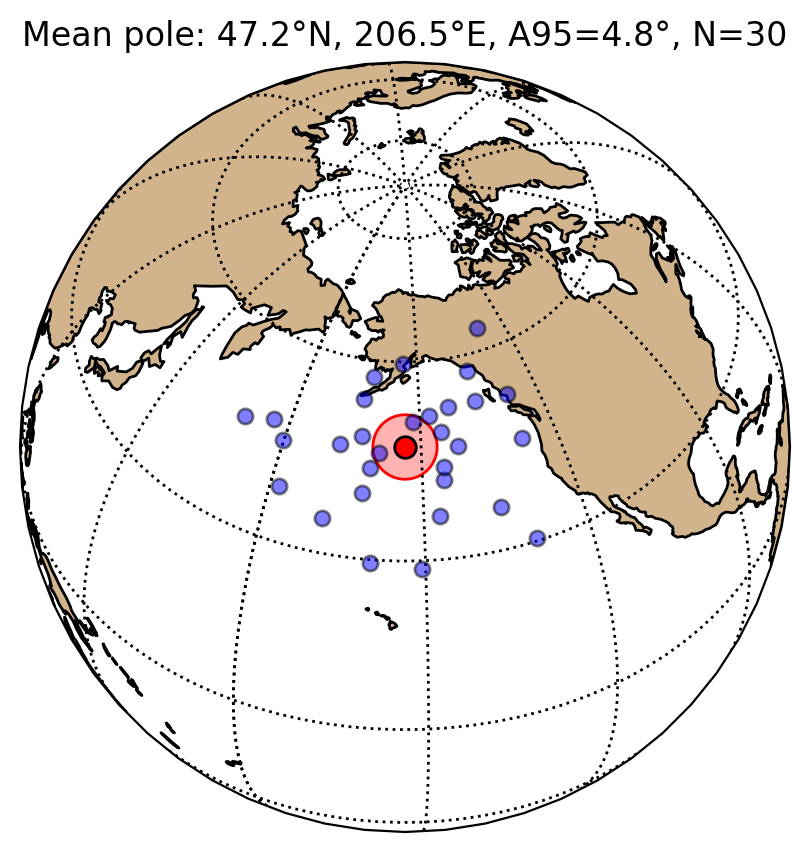

In [4]:
vgp_block, pole_mean = pt.compute_mean_pole(sites_pole, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('\nPublished Pole CCr (Kulakov et al., 2014): 47.2 N, 206.5 E, A95 4.8, K 31, N 30')
pole_plot = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                                  central_latitude=pole_mean['inc'], figsize=(5, 5))

## Site directions (as measured at site)

Dec: 114.8  Inc: -63.7
Number of directions in mean (n): 30
Angular radius of 95% confidence (a_95): 3.6
Precision parameter (k) estimate: 53.5

Published combined A+C direction: D 114.8, I -63.7, a95 3.6, k 54


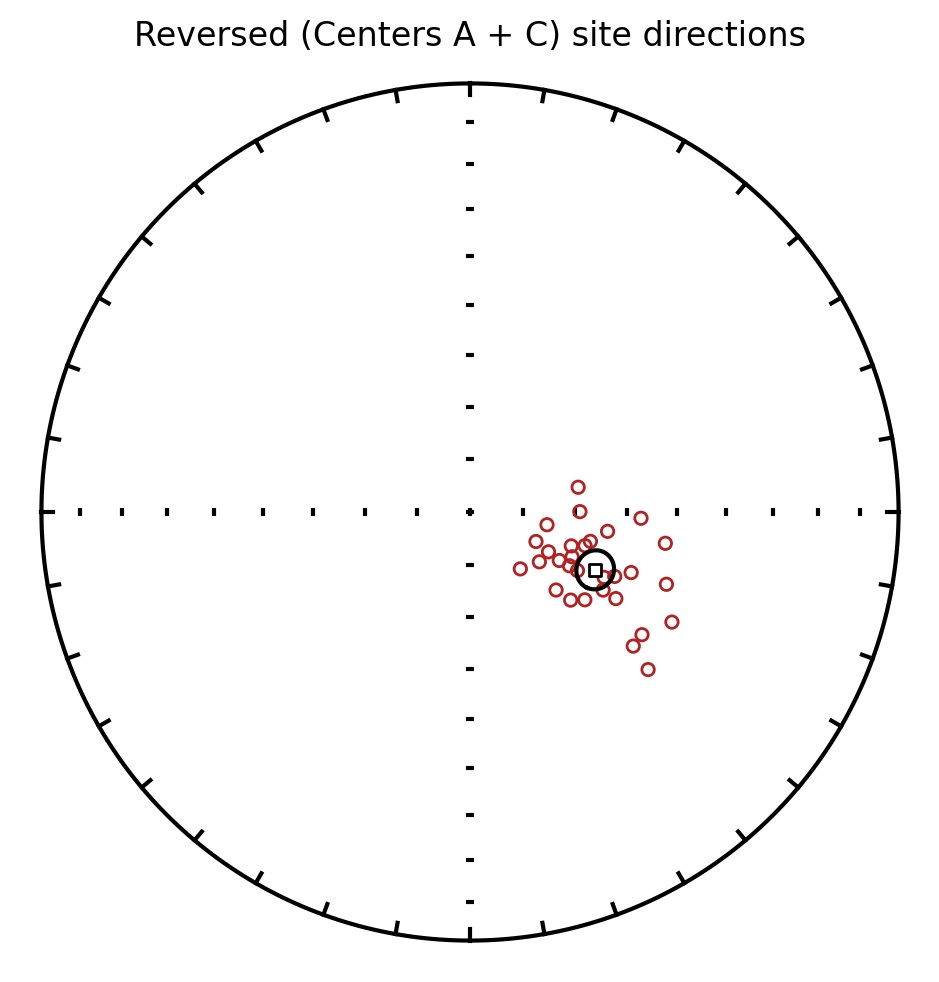

In [5]:
# Centers A + C are all reversed polarity, so report the mean in that (reversed)
# polarity (D ~ 115, I ~ -64; matching the published convention) -> unify_polarity=False
dir_block, dir_mean = pt.compute_mean_direction(sites_pole, unify_polarity=False)
ipmag.print_direction_mean(dir_mean)
print('\nPublished combined A+C direction: D 114.8, I -63.7, a95 3.6, k 54')

ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='firebrick', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], color='black', marker='s')
plt.title('Reversed (Centers A + C) site directions')
plt.show()

## Site direction (calculated from VGPs for common site location)

Dec: 114.8  Inc: -63.7
Number of directions in mean (n): 30
Angular radius of 95% confidence (a_95): 3.6
Precision parameter (k) estimate: 53.4


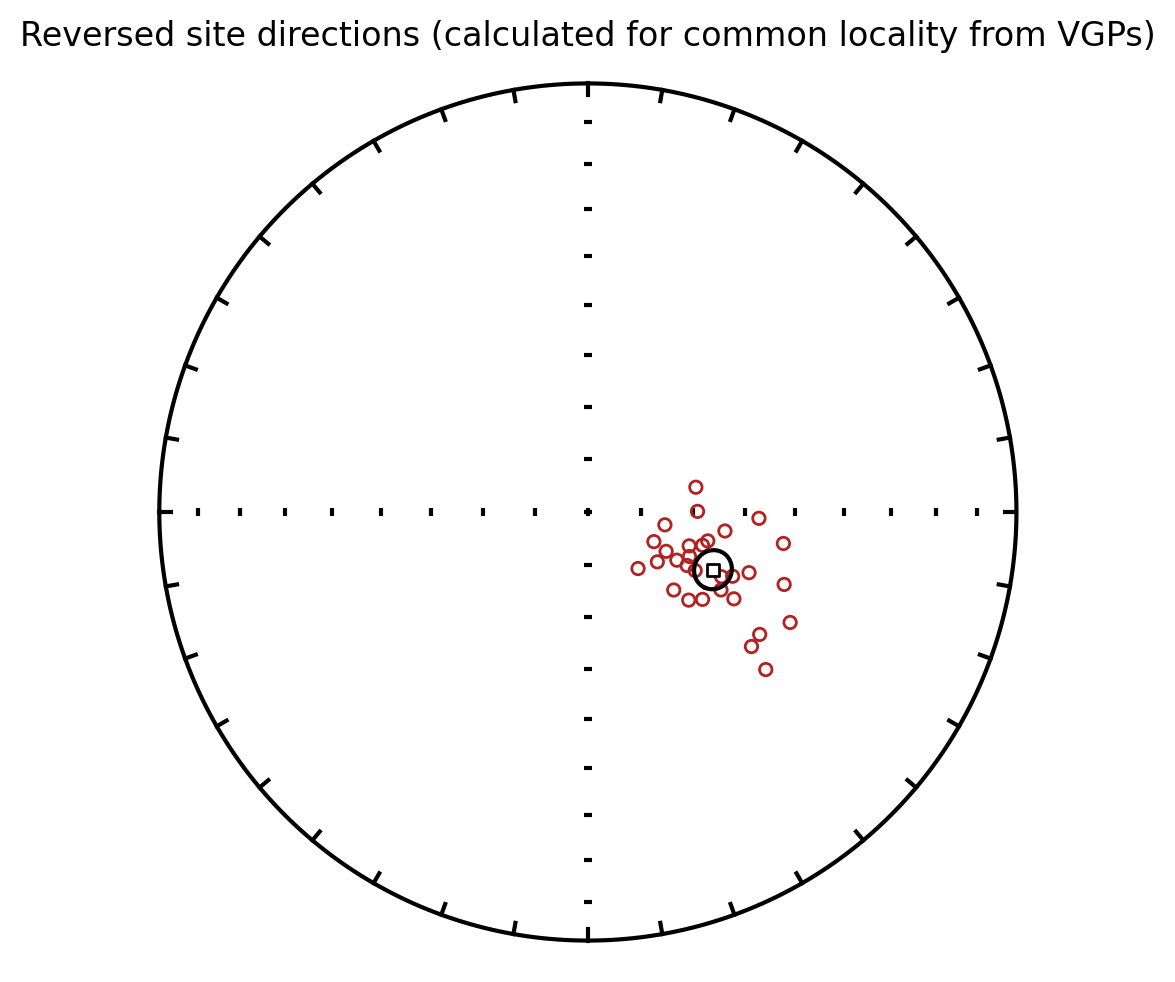

In [6]:
study_lat = 48.79
study_lon = 273.50
dir_block_from_vgps, dir_mean_from_vgps = pt.compute_mean_direction_from_vgps(
    sites_pole, study_lon, study_lat, unify_polarity=False)

ipmag.print_direction_mean(dir_mean_from_vgps)

ipmag.plot_net()
ipmag.plot_di(di_block=dir_block_from_vgps, color='firebrick', marker='o')
ipmag.plot_di_mean(dir_mean_from_vgps['dec'], dir_mean_from_vgps['inc'],
                   dir_mean_from_vgps['alpha95'], color='black', marker='s')
plt.title('Reversed site directions (calculated for common locality from VGPs)')
plt.show()

## Reversal test

The normal-polarity Center B directions and the reversed-polarity Center A + C
directions are compared with the bootstrap and McFadden & McElhinny (1990)
reversal tests. The two groups are antipodal in declination; the test evaluates
whether their mean directions are common (one group inverted to the other's
polarity).

Results of Watson V test: 

Watson's V:           7.1
Critical value of V:  6.6
"Fail": Since V is greater than Vcrit, the two means can
be distinguished at the 95% confidence level.

M&M1990 classification:

Angle between data set means: 7.0
Critical angle for M&M1990:   6.7


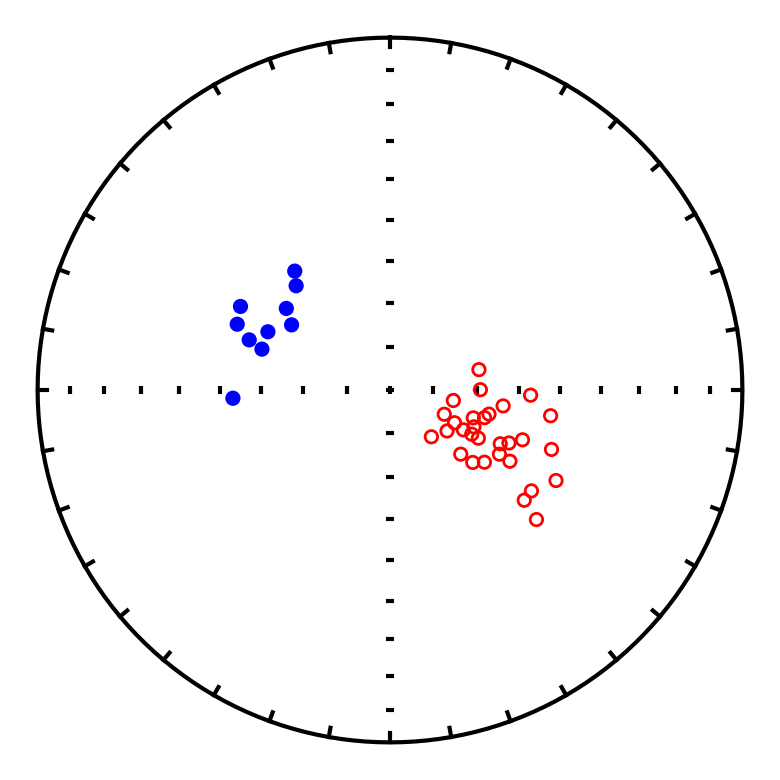

In [7]:
all_dirs = ipmag.make_di_block(sites_geo['dir_dec'].tolist(), sites_geo['dir_inc'].tolist())
ipmag.reversal_test_MM1990(di_block=all_dirs, plot_stereo=True, random_seed=23)
plt.show()

### All-centers combined pole

For comparison, combining all 40 sites — the 30 reversed (Centers A + C) plus the
10 normal-polarity Center B sites, unified to a common polarity — gives the
"Centers A, B, and C" pole of Kulakov et al. (2014, Table 4). It lies ~3.5° in
longitude from the preferred reversed-only Pole CCr because it folds in the normal
Center B directions; Kulakov et al. adopt the reversed-only CCr as the Coldwell
pole.

In [8]:
vgp_block_all, pole_mean_all = pt.compute_mean_pole(sites_geo, unify_polarity=True)
ipmag.print_pole_mean(pole_mean_all)
print('\nKulakov et al. (2014) Table 4, Centers A, B, and C: 46.8 N, 203.1 E, A95 4.2, N 40')
print('Preferred Pole CCr (Centers A + C only):            47.2 N, 206.5 E, A95 4.8, N 30')

Plon: 203.1  Plat: 46.8
Number of directions in mean (n): 40
Angular radius of 95% confidence (A_95): 4.2
Precision parameter (k) estimate: 30.6

Kulakov et al. (2014) Table 4, Centers A, B, and C: 46.8 N, 203.1 E, A95 4.2, N 40
Preferred Pole CCr (Centers A + C only):            47.2 N, 206.5 E, A95 4.8, N 30


## Pole in the context of the Laurentia APWP

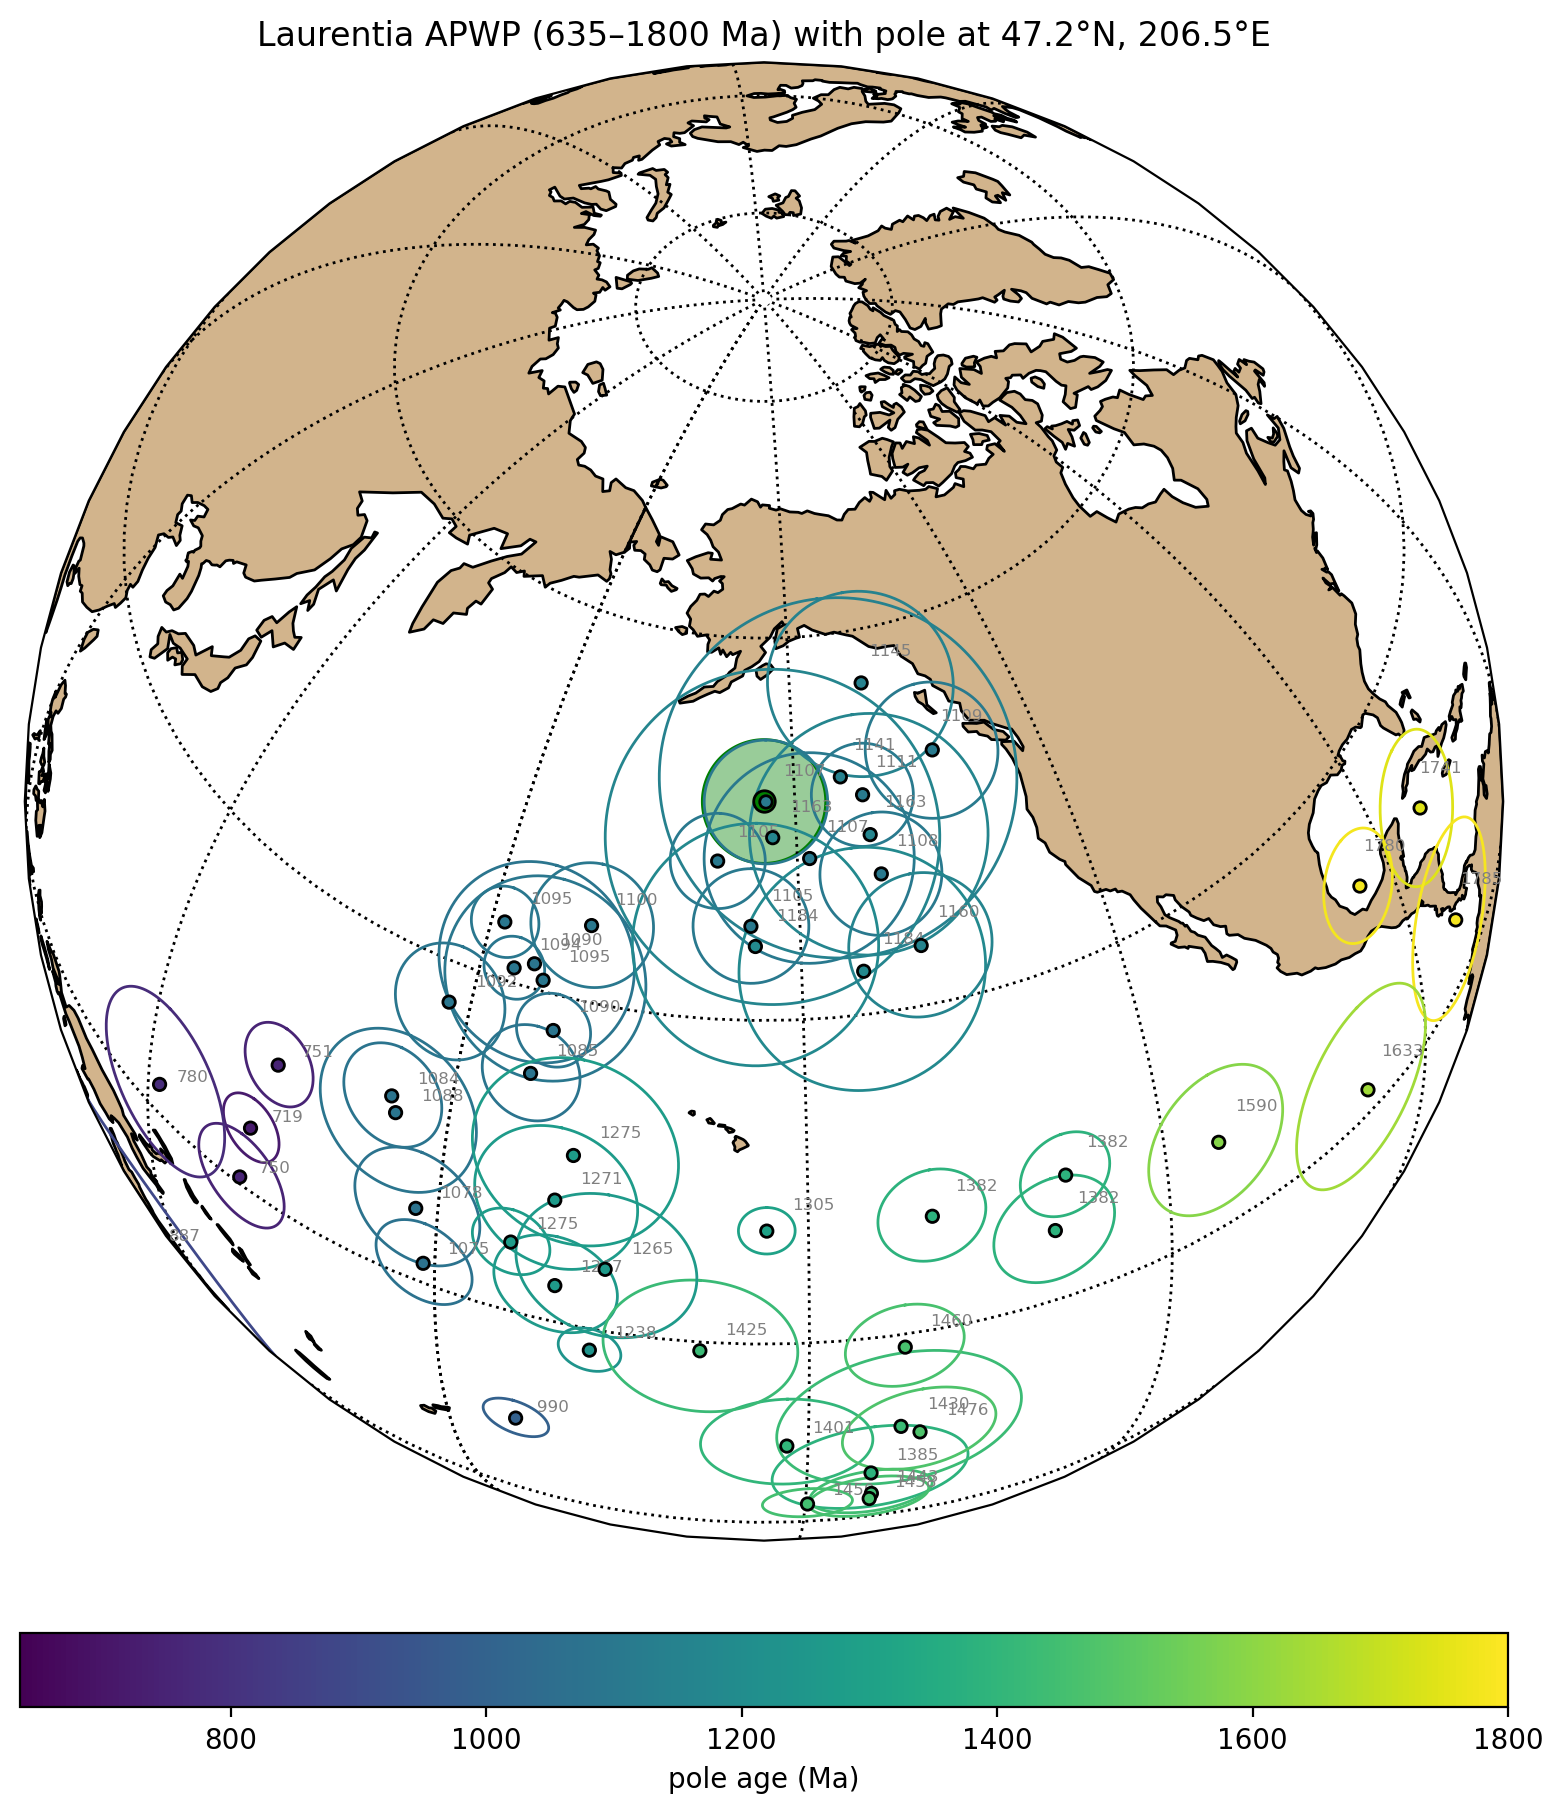

In [9]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R2: Techniques and statistical analysis (Meert et al., 2020)

R2 assessment (Meert et al., 2020):
  (a) two demag methods (AF + thermal)  [advisory, from method_codes]: yes
  (b) PCA / great-circle component analysis  [advisory, from method_codes]: yes
      note: method codes are inconsistently applied; confirm (a)/(b) against the source publication.
  (c) adequate PSV sampling [scored]:
        N = 177 samples (>= 25): PASS
        K = 31.0 (10-70): PASS
        B = 30 sites (>= 8): PASS
        min 3 samples/site (>= 3): PASS
        A95 = 4.8 in Deenen envelope [3.1, 9.6]: PASS
  => R2 (from sub-criterion c) = 1

A_95 of 4.8 passes Deenen et al. (2011) criteria of being between 3.1 and 9.6 for this number of sites


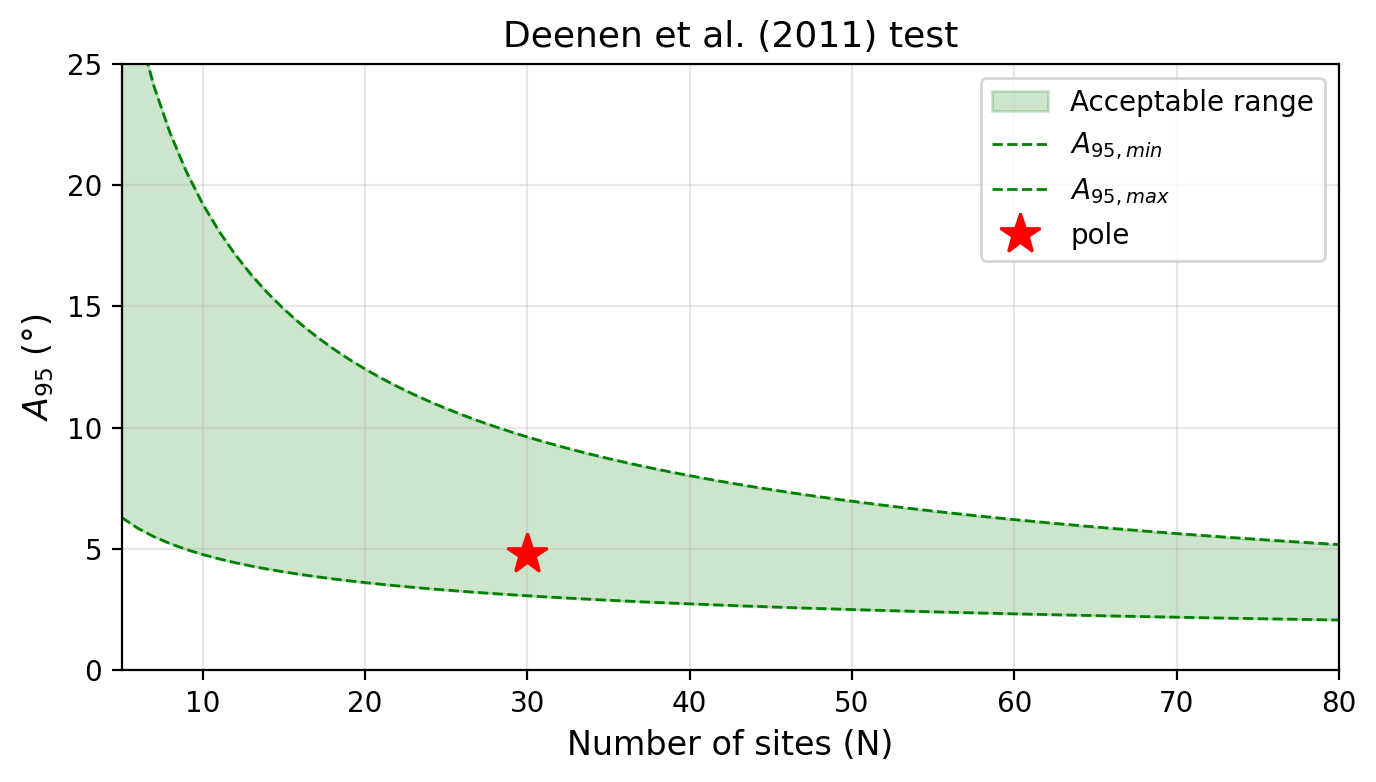

In [10]:
r2 = pt.assess_R2(sites_pole, pole_mean)
print()
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)
plt.show()

### Supplementary: VGP distribution-shape diagnostics (Fisher Q-Q and SVEI)

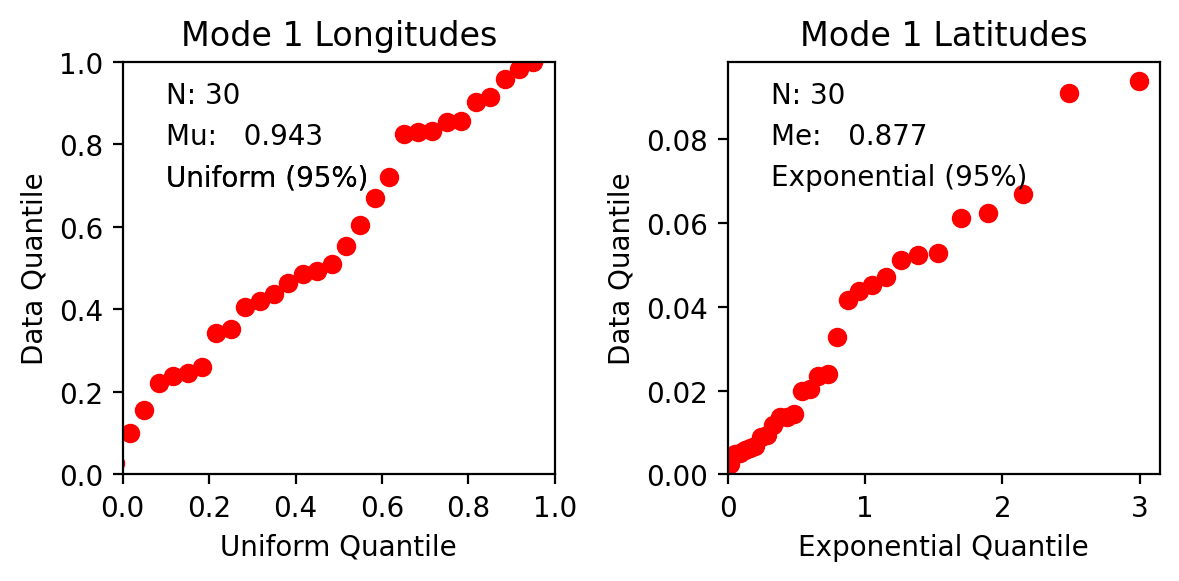

In [11]:
fishqq_result = pt.fishqq_vgps(sites_pole, unify_polarity=True)
plt.show()

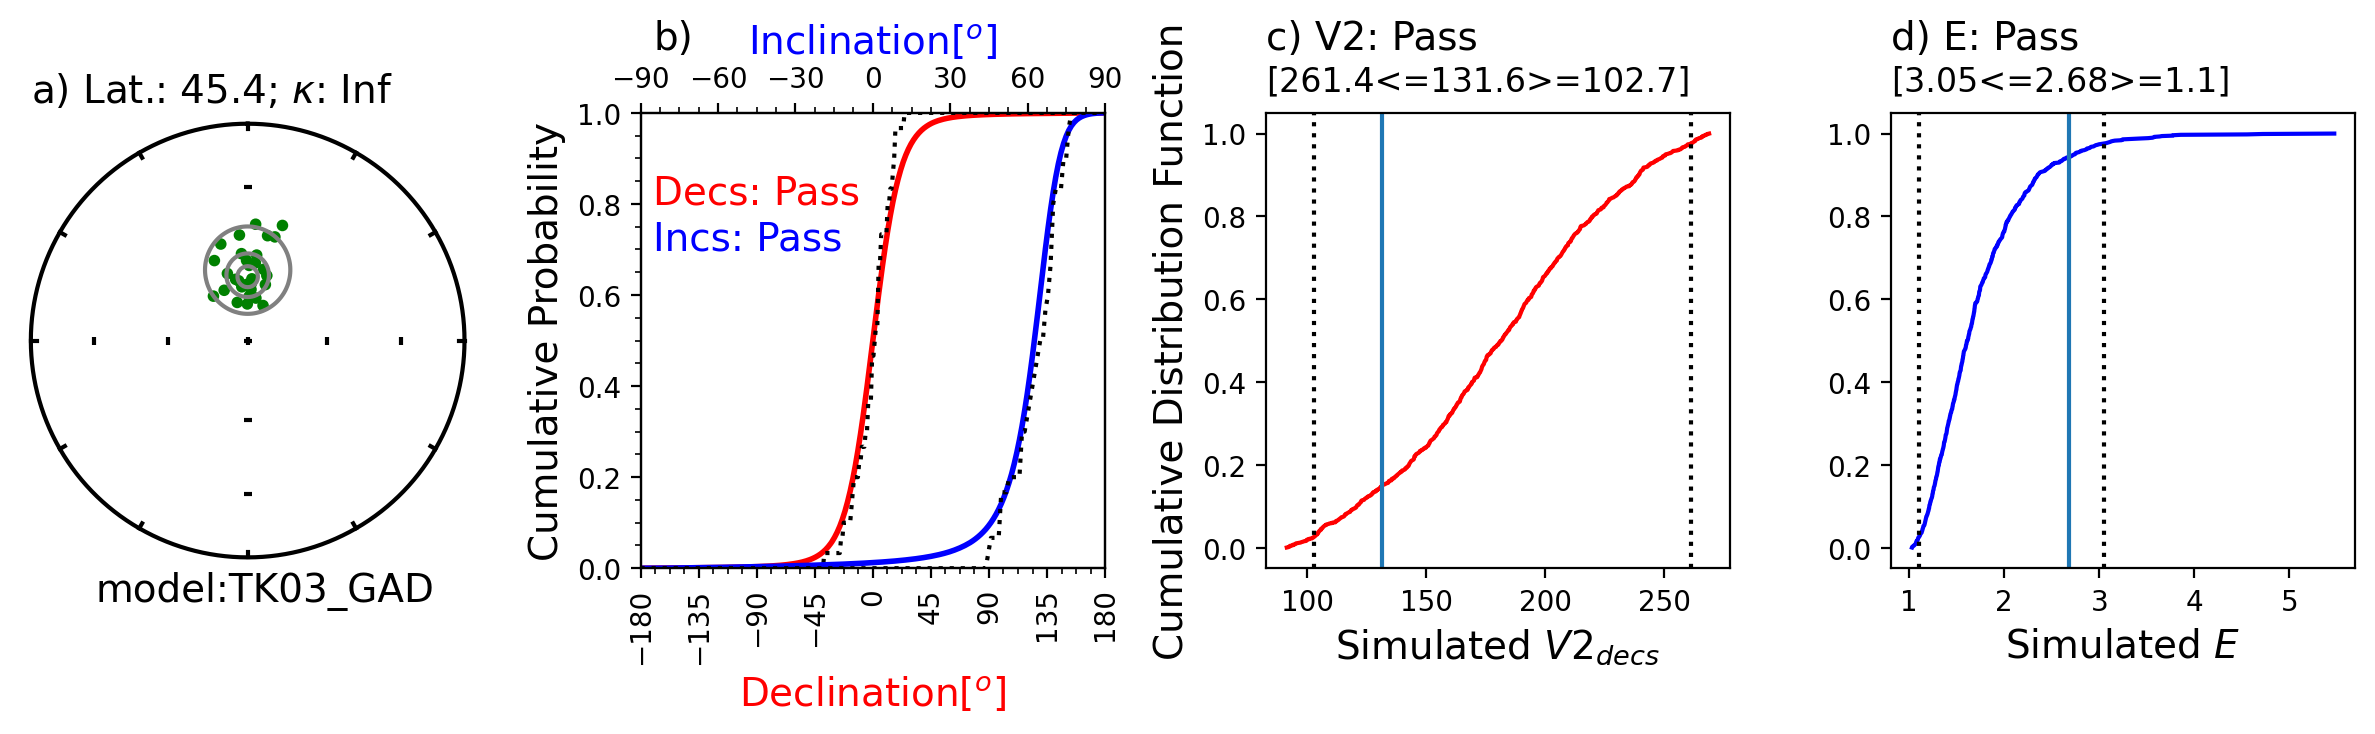

In [12]:
svei_result = pt.svei_test_vgps(sites_pole, study_lon, study_lat, model='TK03_GAD', plot=True)
plt.show()

## R7: comparison with younger Laurentia poles

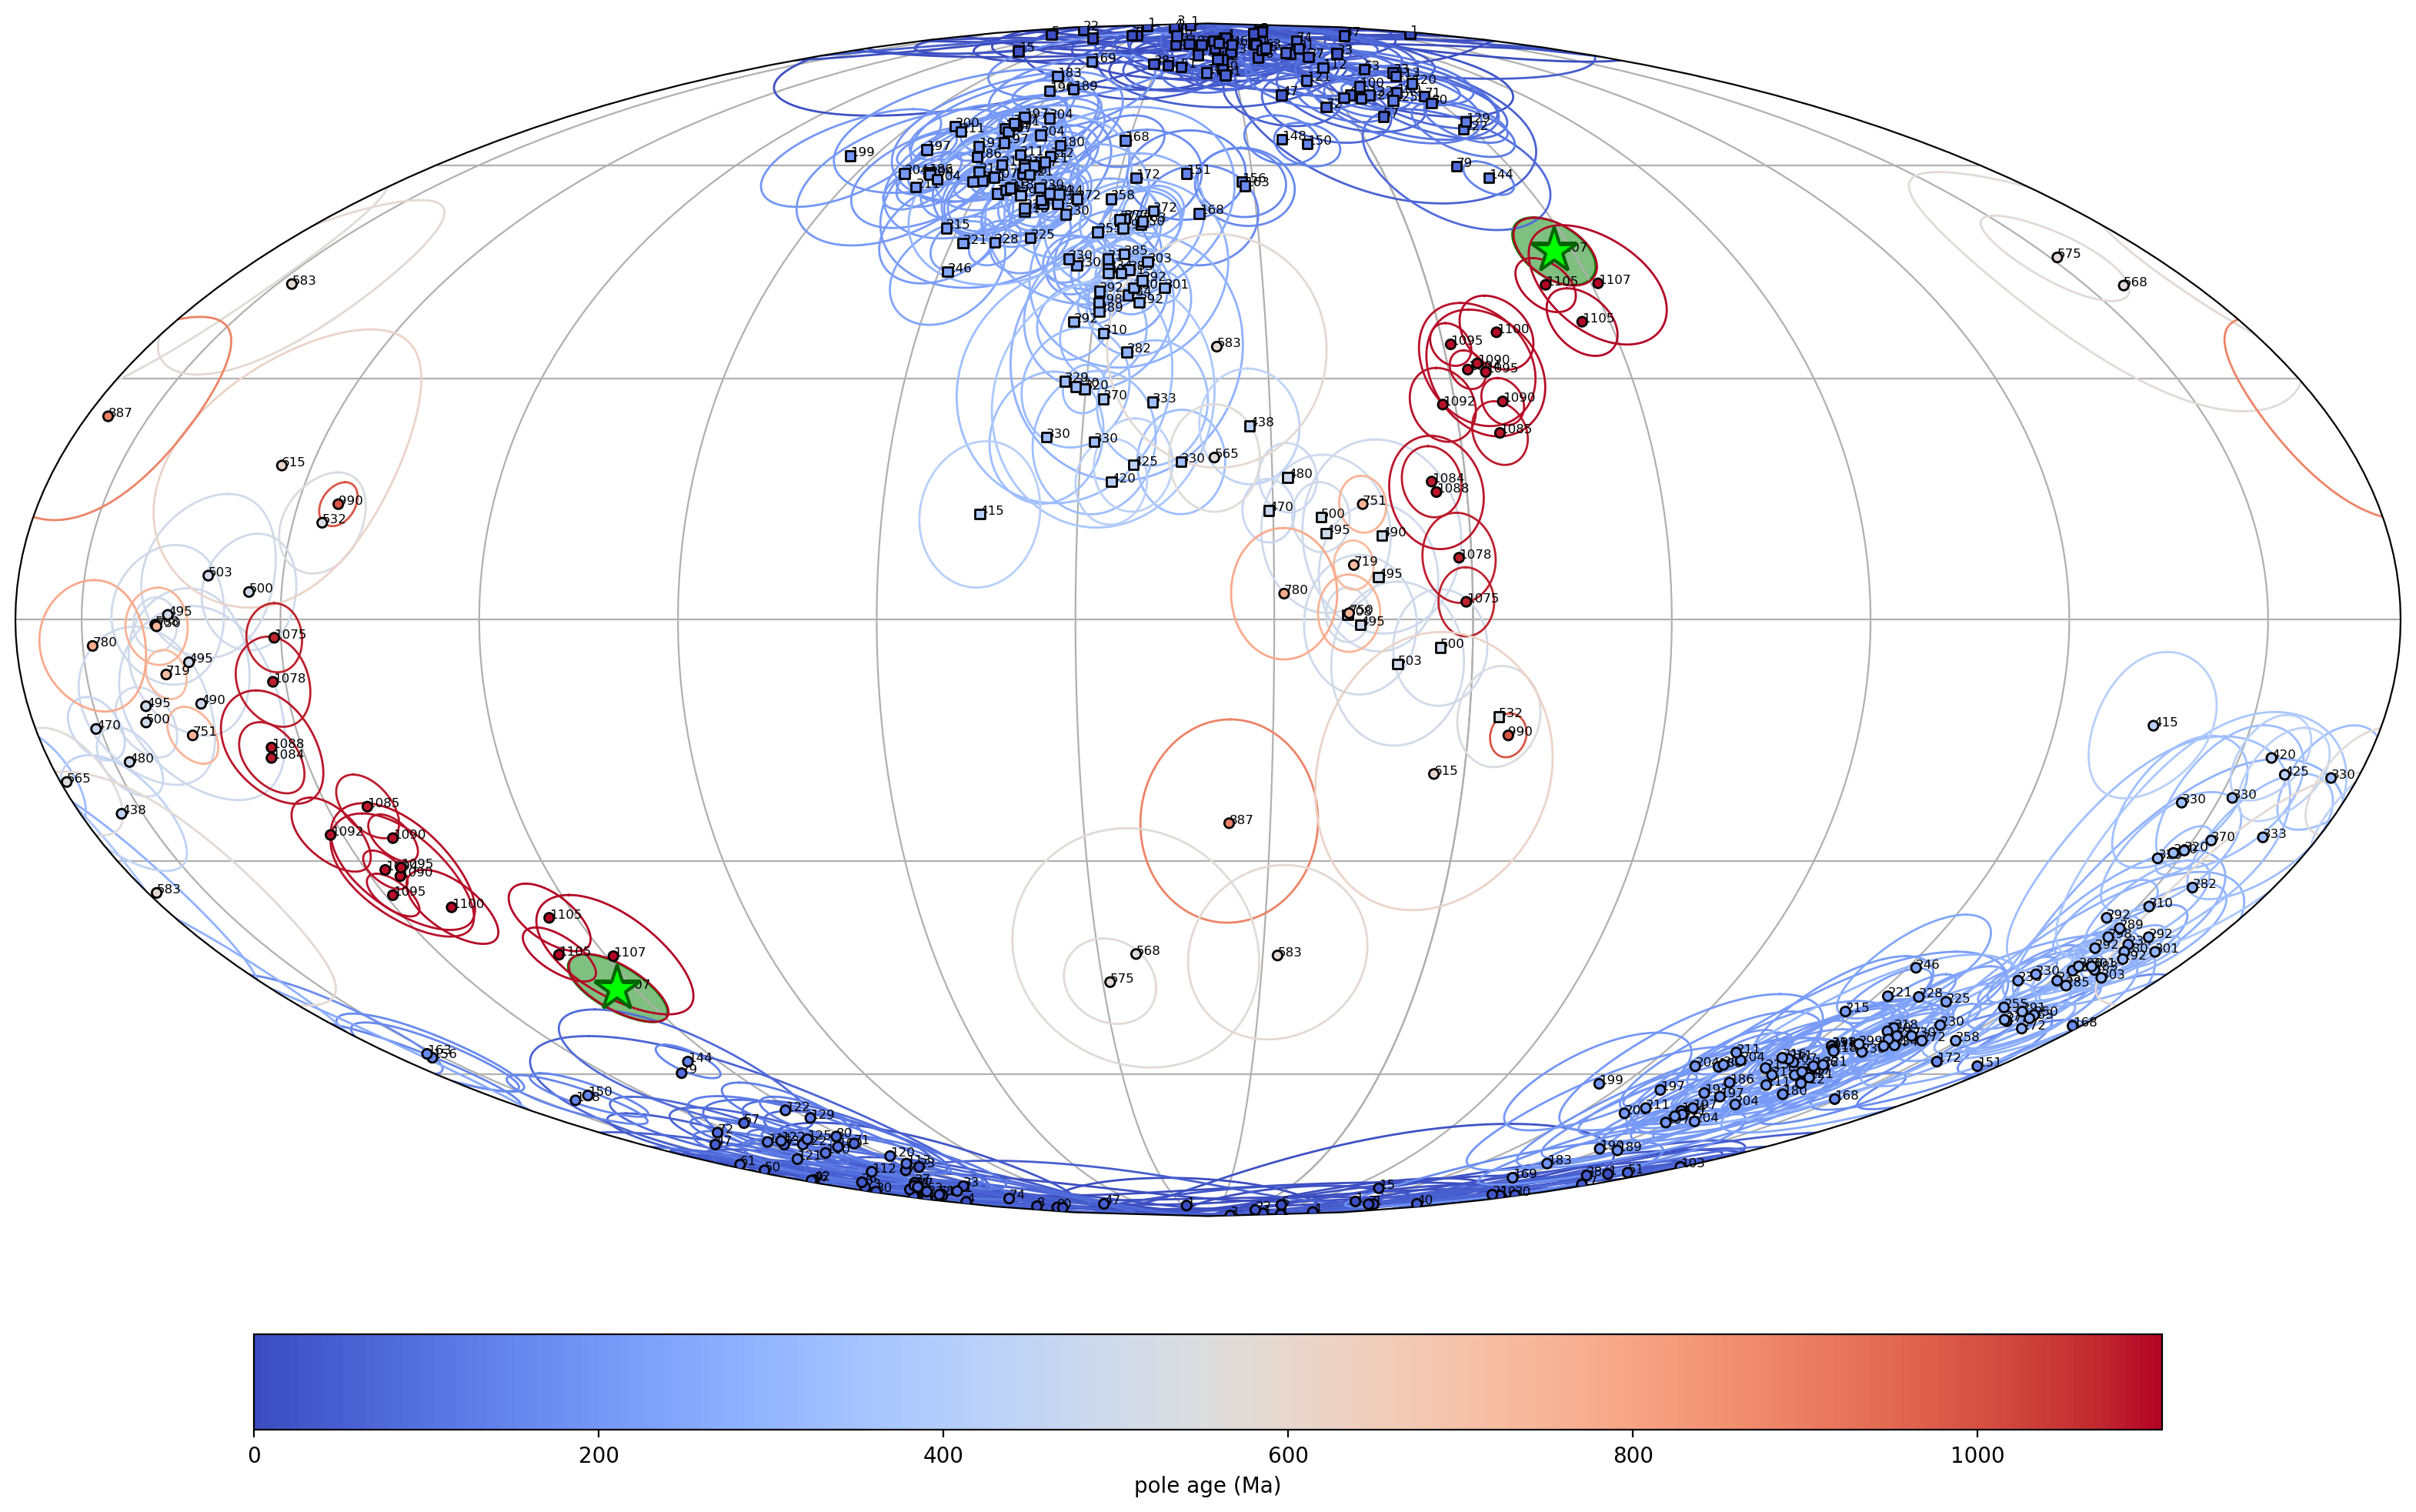

<GeoAxes: >

In [13]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Coldwell Complex', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1107)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | U-Pb zircon/baddeleyite dates on the eastern gabbro of 1108 ± 1 Ma and 1107 +5/−1 Ma (Heaman & Machado, 1992). |
| 2 | Techniques and statistical analysis | **1** | AF, thermal, and combined demagnetization with PCA; B = 30 sites (≥ 8), 177 samples (≥ 25), K = 31 (within 10–70), A95 = 4.8°; PSV adequately sampled (Deenen test). |
| 3 | Magnetic mineralogy characterized | **1** | Hysteresis indicates a low-to-intermediate-coercivity, pseudo-single-domain magnetite/titanomagnetite carrier, with no hematite (Kulakov et al., 2014). |
| 4 | Field tests constrain age of magnetization | **0** | No baked-contact, fold, or conglomerate test is available. |
| 5 | Structural control / tectonic coherence | **1** | The complex is in the autochthonous interior of the Superior Province; as an intrusive body it requires no tilt or tectonic restoration. |
| 6 | Presence of reversals | **1** | Mixed polarity (10 normal-polarity Center B sites + 30 reversed-polarity Centers A + C). Kulakov et al. (2014) report a class-'C' (marginal) McFadden & McElhinny (1990) reversal test; recomputed here, the normal and reversed group means differ by ~7°, near the critical-angle boundary. |
| 7 | No resemblance to younger poles | **1** | The pole agrees with other ca. 1107 Ma Keweenawan poles and is distinct from younger Laurentia poles; its age is independently fixed by U-Pb geochronology. |
| | Total | **6/7** | Grade B |

## Nordic workshop ranking

### Coldwell Complex (Pole CCr) pole

| | This study (site VGPs) | Kulakov et al. (2014) | Previous Nordic compilation |
|---|---|---|---|
| Component | Reversed ChRM (magnetite), Centers A + C | Pole CCr (Centers A + C) | Combined Result |
| N (sites) | 30 | 30 | 40 |
| N (samples) | 177 | 177 | 238 |
| Dec (°) | 114.8 | 114.8 | 114.8 |
| Inc (°) | −63.7 | −63.7 | −63.7 |
| k (direction) | 53.5 | 54 | 50.4 |
| α95 (direction, °) | 3.6 | 3.6 | 3.6 |
| Pole lat (°N) | 47.2 | 47.2 | 47.2 |
| Pole lon (°E) | 206.5 | 206.5 | 206.7 |
| A95 | 4.8 | 4.8 | 4.8 |
| dp / dm (°) | — | — | 4.8 / 4.8 |

The previous Nordic compilation lists the **reversed-only Pole CCr position**
(47.2°N, 206.7°E, A95 4.8°; D = 114.8°, I = −63.7°) but pairs it with the
**all-40-site count** (B = 40, N = 238) — its site total includes the 10
normal-polarity Center B sites that are *not* part of that pole. Combining all 40 reversed + normal sites instead gives a distinct pole, 46.8°N,
203.1°E (A95 4.2°; Kulakov et al., 2014, Table 4, "Centers A, B, and C"), computed
above.

In [14]:
Coldwell_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Coldwell Complex',
    sites=sites_pole,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Characteristic remanent magnetization (ChRM); reversed-polarity Centers A + C (Pole CCr)',
    tests='reversal test conducted between normal (Center B) and reversed (Centers A+C) groups (McFadden & McElhinny, 1990)',
    gpmdb_number='9838',
    percent_reversed=75,
    demag_code=4,
    R1=1, R2=1, R3=1, R4='', R5=1, R6=1, R7=1, Grade='B',
    nominal_age=1107, lomagage=1105, himagage=1109,
    REF_method='U-Pb zircon/baddeleyite dates on the eastern gabbro of 1108 +/- 1 Ma and 1107 +5/-1 Ma (Heaman & Machado, 1992); the complex was emplaced at ca. 1107 Ma during Midcontinent Rift magmatism.',
    POLE_AUTHORS='Kulakov, E. V., Smirnov, A. V., & Diehl, J. F.',
    YEAR=2014,
    JOURNAL='Journal of Geophysical Research: Solid Earth',
    VOLUME=119,
    VPAGES='8633-8654',
    TITLE='Paleomagnetism of the ~1.1 Ga Coldwell Complex (Ontario, Canada): Implications for Proterozoic geomagnetic field morphology and plate velocities',
    COMMENT='Pole reproduced from the site level (Kulakov et al., 2014, Table 2): Fisher mean of the 30 reversed-polarity site VGPs of Centers A and C (Pole CCr), reproducing the published 47.2N/206.5E (A95 4.8, K 31) exactly as documented in Swanson-Hysell et al., 2026. Previous Nordic compilation pole also included the 10 normal-polarity Center B sites.'
)
pt.save_nordic_summary(Coldwell_summary, '1107_Coldwell')
Coldwell_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Coldwell Complex,GPMDB:9838,Characteristic remanent magnetization (ChRM); ...,reversal test conducted between normal (Center...,0,48.79,273.5,30,177,...,1109,U-Pb zircon/baddeleyite dates on the eastern g...,Coldwell Complex,"Kulakov, E. V., Smirnov, A. V., & Diehl, J. F.",2014,Journal of Geophysical Research: Solid Earth,119,8633-8654,Paleomagnetism of the ~1.1 Ga Coldwell Complex...,Pole reproduced from the site level (Kulakov e...
